### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('data/coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [5]:
data.isna()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12680,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12681,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12682,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


3. Decide what to do about your missing data -- drop, replace, other...

In [9]:
#use the dropna function
data.dropna()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1237,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,26,Single,...,4~8,4~8,1~3,never,1,0,0,0,1,1
1238,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,26,Single,...,4~8,4~8,1~3,never,1,0,0,0,1,0
1239,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,26,Single,...,4~8,4~8,1~3,never,1,0,0,0,1,1
1240,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,26,Single,...,4~8,4~8,1~3,never,1,1,0,0,1,0
1241,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,26,Single,...,4~8,4~8,1~3,never,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8293,Work,Alone,Rainy,55,7AM,Restaurant(<20),2h,Male,21,Single,...,less1,1~3,less1,less1,1,1,1,0,1,1
8294,Work,Alone,Rainy,55,7AM,Restaurant(20-50),1d,Male,21,Single,...,less1,1~3,less1,less1,1,1,1,0,1,1
8295,Work,Alone,Snowy,30,7AM,Restaurant(<20),2h,Male,21,Single,...,less1,1~3,less1,less1,1,1,1,0,1,1
8296,Work,Alone,Snowy,30,7AM,Restaurant(20-50),1d,Male,21,Single,...,less1,1~3,less1,less1,1,1,1,0,1,1


4. What proportion of the total observations chose to accept the coupon?



In [10]:
#we note that 1 = yes and 0 = no for those who accepted the coupon as indicated by the Y column
#check first with the value_counts method
data['Y'].value_counts()
#since the values are binary we can also check using the sum method
accepted = data['Y'].sum()
print(accepted)

7210


5. Use a bar plot to visualize the `coupon` column.

<function matplotlib.pyplot.show(close=None, block=None)>

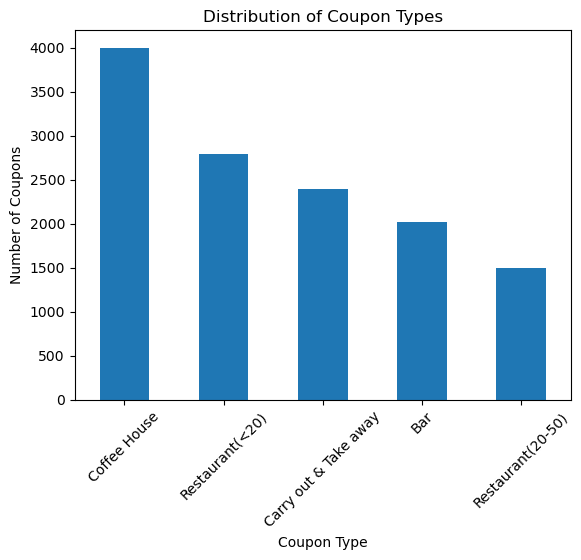

In [11]:
#use pandas to visualize the coupon column
data['coupon'].value_counts().plot(kind = 'bar')
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Number of Coupons')
plt.xticks(rotation = 45)
plt.show

6. Use a histogram to visualize the temperature column.

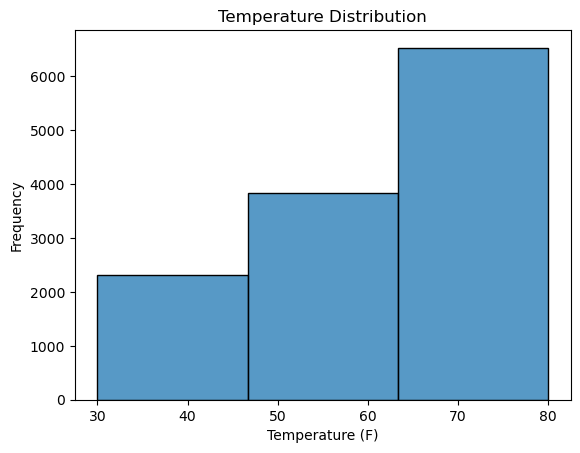

In [12]:
sns.histplot(data = data , x = 'temperature', bins = 3)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (F)')
plt.ylabel('Frequency')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [13]:
bar_coupons = data[data['coupon'] == 'Bar']

2. What proportion of bar coupons were accepted?


In [17]:
bar_coupons['Y'].value_counts()

#bar_coup_accepted = bar_coupons['Y'].sum()
#print(bar_coup_accepted)
bc_accepted = bar_coupons['Y'].mean()
print(bc_accepted)

#827 bar coupons were accepted out of 2017 total, so the proportion is 0.410

0.41001487357461575


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [19]:
low_visit = bar_coupons[bar_coupons['Bar'].isin(['never', 'less1', '1~3'])] #visit bar 3 or fewer times
high_visit = bar_coupons[bar_coupons['Bar'].isin(['4~8', 'gt8'])] #visit bar more than 3 times a month

In [20]:
#check the sum of acceptance rates for the respective visiting groups
low_rate = low_visit['Y'].mean()
high_rate = high_visit['Y'].mean()
print(low_rate)
print(high_rate)

0.37061769616026713
0.7688442211055276


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [21]:
#create target group that visit the bar more than once a month and are over the age of 25, 
target =bar_coupons[(bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) & (bar_coupons['age'].isin(['26','31', '36', '41', '46', '50plus']))]
other = bar_coupons.drop(target.index)

In [22]:
#calculate acceptance rates for the resepective groups and print the result
target_rate = target['Y'].mean()
other_rate = other['Y'].mean()

print(target_rate)
print(other_rate)

#There is a significant difference between drivers who go to a bar more than once a month and are over 25 years old

0.6952380952380952
0.33500313087038197


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [28]:
#repeat the same process as for 4.
farm_bar = bar_coupons[((bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) & (bar_coupons['passanger'] != 'Kid(s)') & (bar_coupons['occupation'] != 'Farming Fishing & Forestry'))]
others_group = bar_coupons.drop(farm_bar.index)

In [29]:
farm_bar_rate = farm_bar['Y'].mean()
others_group_rate = others_group['Y'].mean()
print(farm_bar_rate)
print(others_group_rate)

0.7132486388384754
0.296043656207367


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [32]:
#repeat the process for these 3 conditions:
g1 = (
    bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['maritalStatus'] != 'Widowed')
)
g2 = (
    bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    bar_coupons['age'].isin(['below21', '21', '26'])
)
g3 =  (
    bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8']) &
    bar_coupons['income'].isin([
        'Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999'
    ])
)

In [36]:
#combine these 3 group conditions: 
target2 = bar_coupons[g1 | g2 | g3]
other2 = bar_coupons.drop(target2.index)

In [37]:
target2_rate = target2['Y'].mean()
other2_rate = other2['Y'].mean()

print(target2_rate)
print(other2_rate)

0.5889175257731959
0.29814665592264306


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [38]:
#I would hypothesize that drivers who accepted the bar coupons tend to be older than 25, have passengers that are not kids, and are likely to visit more than 3 times a month. 
#The last point would especially be intuitive because people who tend to frequent bars more often would be more likely to look for ways to save on their spending

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [40]:
#Create a DataFrame for coffee house coupons
cf_coupons =  data[data['coupon'] ==  'Coffee House']

In [41]:
#check the acceptance rate of the coffee house group
cf_accepted = cf_coupons['Y'].mean()
print(cf_accepted)

0.49924924924924924


In [42]:
#Check acceptance rates based on how often they visit the coffee house, one group being less than 3 times, other group being 4+ times a month
low_cf = cf_coupons[cf_coupons['CoffeeHouse'].isin(['never', 'less1', '1~3'])] #visit bar 3 or fewer times
high_cf = cf_coupons[cf_coupons['CoffeeHouse'].isin(['4~8', 'gt8'])] #visit bar more than 3 times a month

lowCFRate = low_cf['Y'].mean()
highCFRate = high_cf['Y'].mean()
print(lowCFRate)
print(highCFRate)

0.44940867279894875
0.675


In [54]:
#Check Acceptance Rate for people who are alone vs accompanied by a kid or another passanger
target = cf_coupons[cf_coupons['passanger'] == 'Alone']
other = cf_coupons.drop(target.index)
target_rate = target['Y'].mean()
other_rate = other['Y'].mean()
print(target_rate)
print(other_rate)

0.4379432624113475
0.578735632183908


In [46]:
#Check acceptance rate of drivers whose marital status are single or have unmarried partners and who are not unemployed
target = cf_coupons[(cf_coupons['maritalStatus'].isin(['Single', 'Unmarried partner'])) & (cf_coupons['occupation'] != 'Unemployed')]
other = cf_coupons.drop(target.index)

In [47]:
target_rate = target['Y'].mean()
other_rate = other['Y'].mean()
print(target_rate)
print(other_rate)

0.49588477366255146
0.5024366471734892


In [52]:
#Check acceptance rate for drivers whose ages are above 25, visit coffee houses at least times a month, and are not unemployed
cond = (cf_coupons['age'].isin(['26','31', '36', '41', '46', '50plus']) & (cf_coupons['occupation'] != 'Unemployed') & (cf_coupons['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])))
target = cf_coupons[cond]
other = cf_coupons.drop(target.index)
target_rate = target['Y'].mean()
other_rate = other['Y'].mean()
print(target_rate)
print(other_rate)

0.6313594662218516
0.4426170897390061


In [57]:
#Findings Section:

#Bar Coupons Findings: I would hypothesize that drivers who accepted the bar coupons tend to be older than 25, have passengers that are not kids, and are likely to visit more than 3 times a month. 
#The last point would be expected because people who tend to frequent bars more often would be more likely to look for ways to save on their spending

#Coffee House Findings: Based on what we can observe from the data, we hypothesize that drivers who accept coupons from a coffee house are more likely to be above 25,
#not unemployed, and visit the coffee house at least 1-3 times a month

#In both dataFrames, the most significant difference can be seen with visiting frequency, although it was more noticeable with the bar DataFrame than the CoffeeHouse dataframe